# ML Pipeline Frontend

Interactive interface for running ensemble ML experiments on bioinformatics datasets.
Connects to the orchestration service API at http://localhost:8000

In [1]:
import requests
import json
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ORCHESTRATION_URL = "http://localhost:8000"
API_ENDPOINT = f"{ORCHESTRATION_URL}/api/pipeline/run"

print(f"✓ Configured to use: {API_ENDPOINT}")

✓ Configured to use: http://localhost:8000/api/pipeline/run


## Configure and Run Pipeline

In [2]:
# Define pipeline payload directly
payload = {
    "osd_ids": "47,48,137,168",
    "config": {
        "target_column": "Factor Value[Spaceflight]",
        "task_type": "classification",
        "trans_list": "s,l",  # s=standardize, l=log transform
        "ensemble_algorithms": ["random_forest", "logistic_regression", "xgboost", "svm"],
        "hyperparameters": {},
        "metrics": ["accuracy", "precision", "recall", "f1_score"],
        "test_size": 0.2,
        "random_state": 42,
        "min_features": 100,
        "factor_name": "Factor Value[Spaceflight]",
        "factor_values": ["Ground Control", "Space Flight"],
        "fi_methods": ["permutation", "recursive"],
        "convert_ensembl_to_symbol": True,
    }
}

print("Pipeline Configuration:")
print(f"  OSD IDs: {payload['osd_ids']}")
for key, value in payload['config'].items():
    print(f"  {key}: {value}")

Pipeline Configuration:
  OSD IDs: 47,48,137,168
  target_column: Factor Value[Spaceflight]
  task_type: classification
  trans_list: s,l
  ensemble_algorithms: ['random_forest', 'logistic_regression', 'xgboost', 'svm']
  hyperparameters: {}
  metrics: ['accuracy', 'precision', 'recall', 'f1_score']
  test_size: 0.2
  random_state: 42
  min_features: 100
  factor_name: Factor Value[Spaceflight]
  factor_values: ['Ground Control', 'Space Flight']
  fi_methods: ['permutation', 'recursive']
  convert_ensembl_to_symbol: True


## Execute Pipeline

In [3]:
def run_pipeline(payload):
    """Run pipeline with ensemble algorithms and handle streaming responses"""
    
    config = payload['config']
    print(f"Sending request to {API_ENDPOINT}")
    print(f"  OSD IDs: {payload['osd_ids']}")
    print(f"  Algorithms: {', '.join(config['ensemble_algorithms'])}")
    print(f"  Min Features: {config['min_features']}")
    print(f"  Transformations: {config['trans_list']}")
    print(f"\\nThis may take several minutes...\\n")
    
    try:
        response = requests.post(
            API_ENDPOINT,
            json=payload,
            stream=True,
            timeout=600
        )
        
        if response.status_code == 200:
            # Process streaming NDJSON responses
            result = None
            for line in response.iter_lines():
                if line:
                    chunk = json.loads(line)
                    progress = chunk.get('progress_percent', 0)
                    status = chunk.get('status', 'running')
                    message = chunk.get('message', '')
                    
                    print(f"[{progress:3d}%] {status}: {message}")
                    result = chunk
            
            print("\\n✓ Pipeline completed!")
            return result
        else:
            print(f"✗ Error: {response.status_code}")
            print(response.text)
            return None
    except Exception as e:
        print(f"✗ Exception: {e}")
        return None

result = run_pipeline(payload)

Sending request to http://localhost:8000/api/pipeline/run
  OSD IDs: 47,48,137,168
  Algorithms: random_forest, logistic_regression, xgboost, svm
  Min Features: 100
  Transformations: s,l
\nThis may take several minutes...\n
[ 10%] transforming: Applying transformations: s,l...
[ 30%] transforming: Transformations completed
[ 25%] filtering: Filtering features by CV...
[ 30%] filtering: Filtered to 101 features
[ 32%] converting: Converting feature names...
[ 33%] converting: Converted 100 Ensembl IDs to gene symbols
[ 65%] training: Training 4 models
[ 85%] deseq2: Running DESeq2 differential expression analysis...
[ 90%] deseq2: DESeq2: 13 significant genes (0 up, 13 down)
[100%] completed: Pipeline completed successfully
\n✓ Pipeline completed!


## Display Results

In [4]:
if result:
    print("\\n" + "="*80)
    print("PIPELINE RESULTS - ENSEMBLE TRAINING")
    print("="*80)
    
    cfg = result.get('config', {})
    print(f"\\nConfiguration:")
    print(f"  Algorithms: {', '.join(cfg.get('algorithms', []))}")
    print(f"  Target: {cfg.get('target_column')}")
    print(f"  OSD IDs: {cfg.get('osd_ids')}")
    print(f"  Test Size: {cfg.get('test_size')}")
    print(f"  Min Features: {cfg.get('min_features')}")
    
    train = result.get('training_results', {})
    test_metrics = train.get('test_metrics', {})
    
    print(f"\\nEnsemble Training Results:")
    print(f"  Total Models: {test_metrics.get('num_models', 0)}")
    print(f"  Mean Accuracy: {test_metrics.get('mean_accuracy', 0):.4f}")
    
    models = test_metrics.get('models', [])
    if models:
        print(f"\\n  Individual Model Performance:")
        for model in models:
            algo = model.get('algorithm', 'unknown')
            acc = model.get('accuracy', 0)
            prec = model.get('precision', 0)
            rec = model.get('recall', 0)
            f1 = model.get('f1_score', 0)
            print(f"    {algo:20s} → Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")
    
    # Feature importance summary
    fi = result.get('feature_importance', {})
    if fi:
        print(f"\\n  Feature Importance:")
        print(f"    Models with importance: {len(fi)}")
        for model_id in list(fi.keys())[:3]:
            methods = fi[model_id]
            print(f"    {model_id}: {len(methods)} methods computed")
else:
    print("Run pipeline first")

\n================================================================================
PIPELINE RESULTS - ENSEMBLE TRAINING
\nConfiguration:
  Algorithms: random_forest, logistic_regression, xgboost, svm
  Target: Factor Value[Spaceflight]
  OSD IDs: 47,48,137,168
  Test Size: 0.2
  Min Features: 100
\nEnsemble Training Results:
  Total Models: 4
  Mean Accuracy: 0.6042
\n  Individual Model Performance:
    random_forest        → Acc: 0.5000, Prec: 0.5000, Rec: 0.5000, F1: 0.4857
    logistic_regression  → Acc: 0.5833, Prec: 0.6111, Rec: 0.5833, F1: 0.5556
    xgboost              → Acc: 0.5833, Prec: 0.6111, Rec: 0.5833, F1: 0.5556
    svm                  → Acc: 0.7500, Prec: 0.8333, Rec: 0.7500, F1: 0.7333
\n  Feature Importance:
    Models with importance: 4
    model_80e229d3ca2d: 2 methods computed
    model_e88b830a4707: 2 methods computed
    model_b62e978891f5: 2 methods computed


## Visualize Ensemble Model Performance

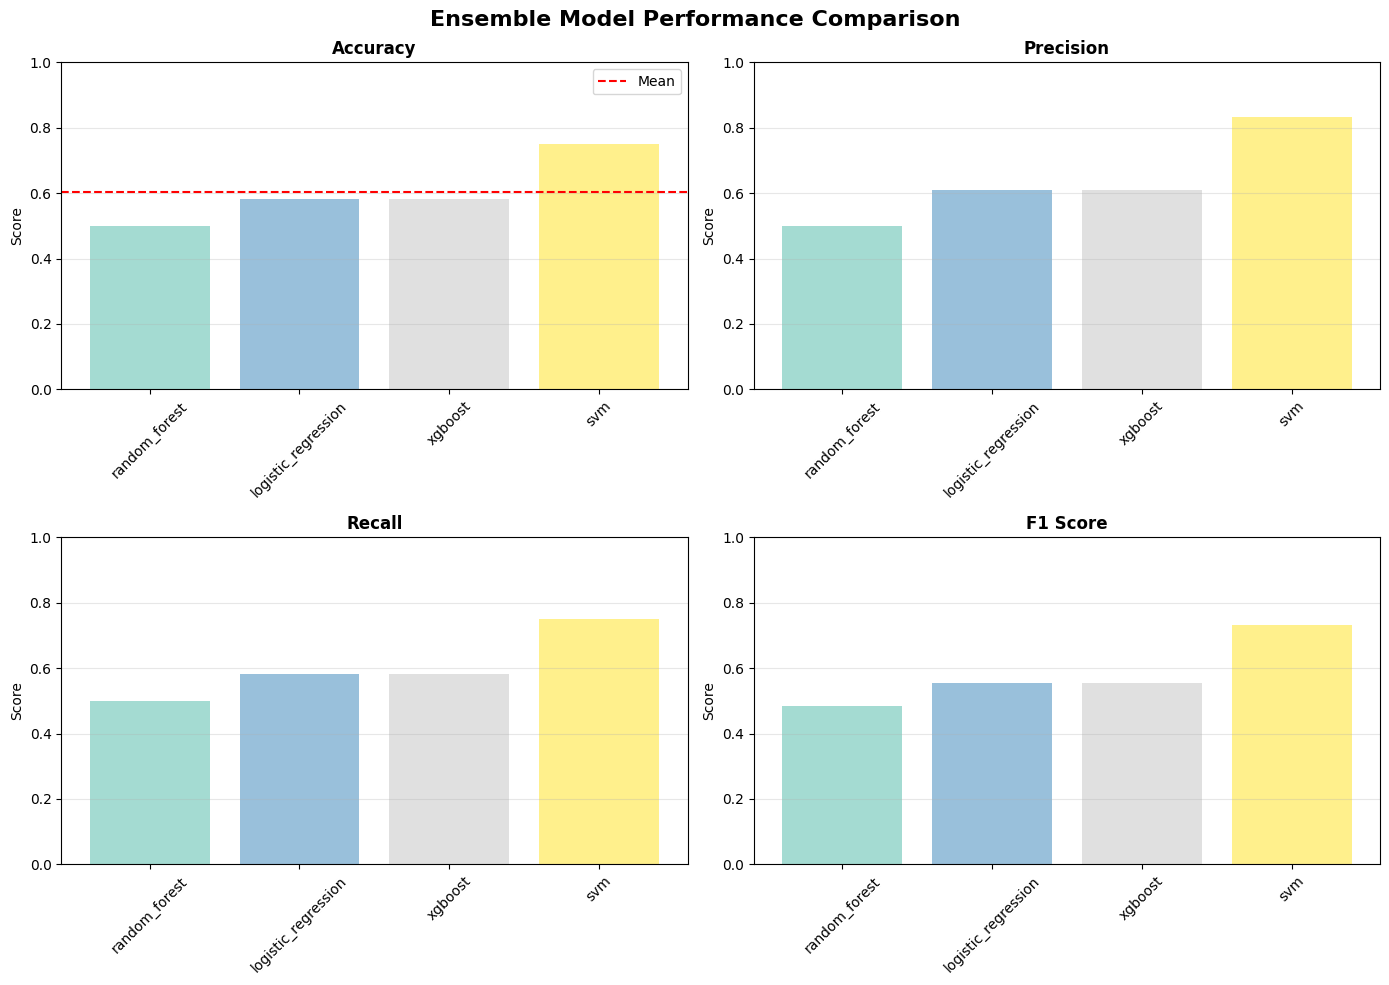

\nModel Ranking (by Accuracy):
                Algorithm  Accuracy  Precision    Recall        F1
Rank                                                              
1                     svm  0.750000   0.833333  0.750000  0.733333
2     logistic_regression  0.583333   0.611111  0.583333  0.555556
3                 xgboost  0.583333   0.611111  0.583333  0.555556
4           random_forest  0.500000   0.500000  0.500000  0.485714


In [5]:
if result:
    train = result.get('training_results', {})
    test_metrics = train.get('test_metrics', {})
    models = test_metrics.get('models', [])
    
    if models and len(models) > 0:
        # Extract metrics for each model
        model_names = [m.get('algorithm', 'unknown') for m in models]
        accuracies = [m.get('accuracy', 0) for m in models]
        precisions = [m.get('precision', 0) for m in models]
        recalls = [m.get('recall', 0) for m in models]
        f1_scores = [m.get('f1_score', 0) for m in models]
        
        # Create comparison plot
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Ensemble Model Performance Comparison', fontsize=16, fontweight='bold')
        
        # Accuracy
        colors = plt.cm.Set3(np.linspace(0, 1, len(model_names)))
        axes[0, 0].bar(model_names, accuracies, color=colors, alpha=0.8)
        axes[0, 0].set_title('Accuracy', fontsize=12, fontweight='bold')
        axes[0, 0].set_ylabel('Score')
        axes[0, 0].set_ylim([0, 1])
        axes[0, 0].grid(axis='y', alpha=0.3)
        axes[0, 0].axhline(y=test_metrics.get('mean_accuracy', 0.5), color='red', linestyle='--', label='Mean')
        axes[0, 0].legend()
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        # Precision
        axes[0, 1].bar(model_names, precisions, color=colors, alpha=0.8)
        axes[0, 1].set_title('Precision', fontsize=12, fontweight='bold')
        axes[0, 1].set_ylabel('Score')
        axes[0, 1].set_ylim([0, 1])
        axes[0, 1].grid(axis='y', alpha=0.3)
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        # Recall
        axes[1, 0].bar(model_names, recalls, color=colors, alpha=0.8)
        axes[1, 0].set_title('Recall', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Score')
        axes[1, 0].set_ylim([0, 1])
        axes[1, 0].grid(axis='y', alpha=0.3)
        axes[1, 0].tick_params(axis='x', rotation=45)
        
        # F1 Score
        axes[1, 1].bar(model_names, f1_scores, color=colors, alpha=0.8)
        axes[1, 1].set_title('F1 Score', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].set_ylim([0, 1])
        axes[1, 1].grid(axis='y', alpha=0.3)
        axes[1, 1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Model ranking table
        ranking_df = pd.DataFrame({
            'Algorithm': model_names,
            'Accuracy': accuracies,
            'Precision': precisions,
            'Recall': recalls,
            'F1': f1_scores
        }).sort_values('Accuracy', ascending=False).reset_index(drop=True)
        
        ranking_df.index = ranking_df.index + 1
        ranking_df.index.name = 'Rank'
        print("\\nModel Ranking (by Accuracy):")
        print(ranking_df.to_string())
    else:
        print("No model metrics available")
else:
    print("Run pipeline first")

## Visualize Feature Importance

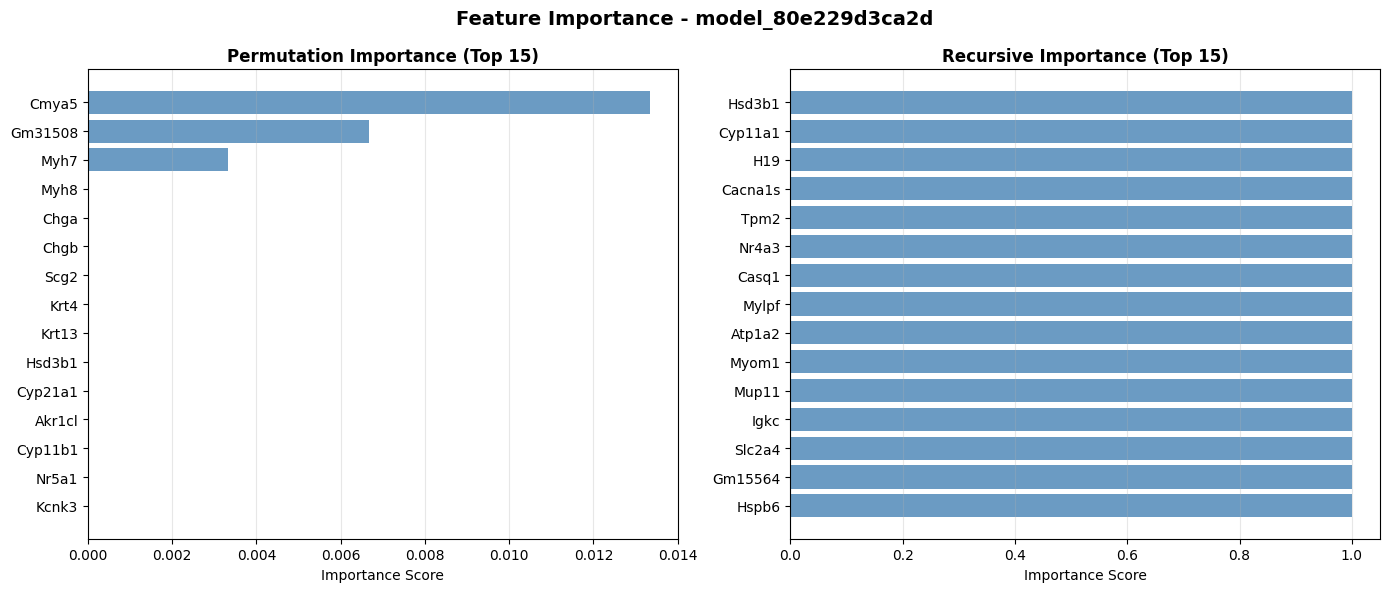

\nTop 10 Features by Permutation Importance (model_80e229d3ca2d):
 Rank Feature  Importance
    1   Cmya5    0.013333
    2 Gm31508    0.006667
    3    Myh7    0.003333
    4    Myh8    0.000000
    5    Chga    0.000000
    6    Chgb    0.000000
    7    Scg2    0.000000
    8    Krt4    0.000000
    9   Krt13    0.000000
   10  Hsd3b1    0.000000


In [6]:
if result:
    fi_data = result.get('feature_importance', {})
    
    if fi_data:
        # Get first model's importance data
        first_model_id = list(fi_data.keys())[0] if fi_data else None
        
        if first_model_id:
            model_importance = fi_data[first_model_id]
            
            # Create subplot for each method
            methods = list(model_importance.keys())
            num_methods = len(methods)
            
            fig, axes = plt.subplots(1, min(num_methods, 2), figsize=(14, 6))
            if num_methods == 1:
                axes = [axes]
            
            fig.suptitle(f'Feature Importance - {first_model_id}', fontsize=14, fontweight='bold')
            
            for idx, method in enumerate(methods[:2]):
                if idx >= len(axes):
                    break
                    
                features_data = model_importance.get(method, {}).get('features', [])
                
                if features_data:
                    # Get top 15 features
                    top_features = sorted(features_data, key=lambda x: x.get('importance', 0), reverse=True)[:15]
                    
                    feature_names = [f.get('feature_name', 'unknown') for f in top_features]
                    importances = [f.get('importance', 0) for f in top_features]
                    
                    # Plot
                    axes[idx].barh(feature_names, importances, color='steelblue', alpha=0.8)
                    axes[idx].set_title(f'{method.capitalize()} Importance (Top 15)', fontweight='bold')
                    axes[idx].set_xlabel('Importance Score')
                    axes[idx].invert_yaxis()
                    axes[idx].grid(axis='x', alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            # Feature importance summary table
            print(f"\\nTop 10 Features by Permutation Importance ({first_model_id}):")
            if 'permutation' in model_importance:
                features = model_importance['permutation'].get('features', [])
                top_10 = sorted(features, key=lambda x: x.get('importance', 0), reverse=True)[:10]
                
                fi_df = pd.DataFrame({
                    'Rank': [f.get('rank', 0) for f in top_10],
                    'Feature': [f.get('feature_name', '') for f in top_10],
                    'Importance': [f.get('importance', 0) for f in top_10]
                })
                print(fi_df.to_string(index=False))
    else:
        print("No feature importance data available")
else:
    print("Run pipeline first")

## DESeq2 Differential Expression Analysis

In [7]:
if result:
    deseq2 = result.get('deseq2_results', {})
    
    if deseq2.get('success'):
        print(f"\nDESeq2 Analysis Results:")
        print(f"  Analysis ID: {deseq2.get('analysis_id')}")
        print(f"  Total genes analyzed: {deseq2.get('num_genes')}")
        print(f"  Significant genes (padj < 0.05): {deseq2.get('num_significant')}")
        print(f"    - Upregulated: {deseq2.get('num_upregulated')}")
        print(f"    - Downregulated: {deseq2.get('num_downregulated')}")
        
        # Top differential genes table
        diff_genes = deseq2.get('differential_genes', [])
        if diff_genes:
            top_genes = sorted(diff_genes, key=lambda x: abs(x.get('log2_fold_change', 0)), reverse=True)[:10]
            
            deseq_df = pd.DataFrame({
                'Gene ID': [g['gene_id'] for g in top_genes],
                'Log2FC': [g['log2_fold_change'] for g in top_genes],
                'P-value': [g['pvalue'] for g in top_genes],
                'Padj': [g['padj'] for g in top_genes],
                'BaseMean': [g['base_mean'] for g in top_genes]
            })
            
            print(f"\nTop 10 Differentially Expressed Genes:")
            print(deseq_df.to_string(index=False))
    else:
        error = deseq2.get('error', 'Unknown error')
        print(f"DESeq2 analysis failed: {error}")
else:
    print("Run pipeline first")


DESeq2 Analysis Results:
  Analysis ID: deseq2_symbols_filtered
  Total genes analyzed: 100
  Significant genes (padj < 0.05): 13
    - Upregulated: 0
    - Downregulated: 13

Top 10 Differentially Expressed Genes:
  Gene ID    Log2FC      P-value         Padj      BaseMean
    Mup11 -4.693714 1.614675e-15 1.614675e-13    200.879932
  Gm31508 -2.954686 2.575368e-07 1.287684e-05    103.065207
  Gm15564 -2.657704 4.758757e-04 6.144261e-03    308.012265
  Gm56534 -2.642690 4.287597e-06 1.429199e-04     88.443488
      Cfd -2.503941 5.529835e-04 6.144261e-03     17.978702
  Gm55276 -2.127609 3.937775e-03 3.281479e-02     71.011758
Rn18s-rs5 -1.986325 5.256323e-04 6.144261e-03 728277.517356
     Ryr1 -1.781746 3.008039e-05 7.520097e-04     31.468567
   Slc4a1 -1.696816 1.240813e-04 2.481627e-03     66.448558
    Cmya5 -1.487203 8.155392e-04 8.155392e-03     24.262039


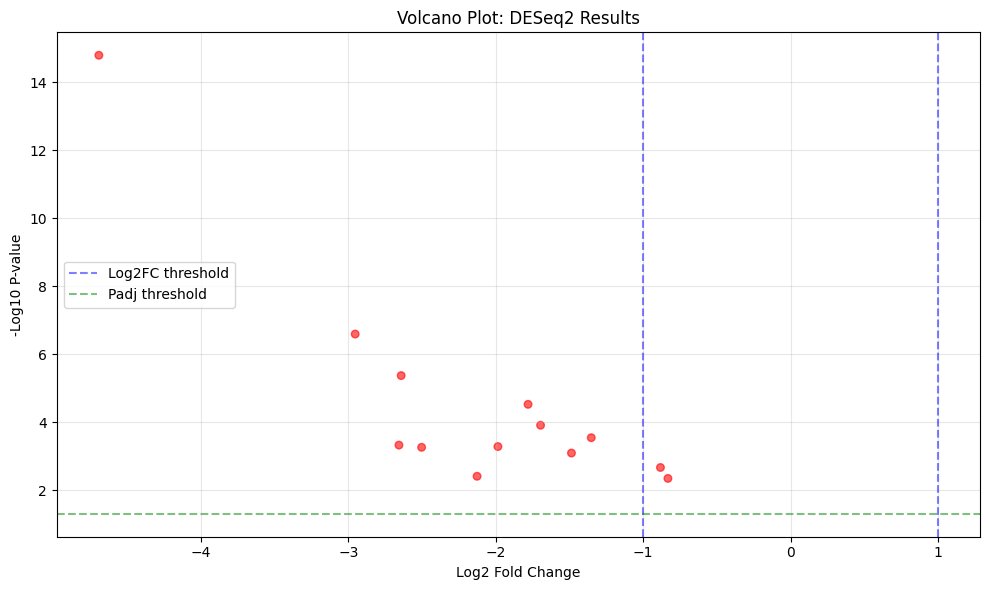

In [8]:
if result:
    deseq2 = result.get('deseq2_results', {})
    
    if deseq2.get('success'):
        diff_genes = deseq2.get('differential_genes', [])
        if diff_genes:
            fig, ax = plt.subplots(figsize=(10, 6))
            log2fc = [g['log2_fold_change'] for g in diff_genes]
            neg_log10_pval = [-np.log10(max(g['pvalue'], 1e-300)) for g in diff_genes]
            
            # Color by significance
            colors = ['red' if g['padj'] < 0.05 else 'gray' for g in diff_genes]
            
            ax.scatter(log2fc, neg_log10_pval, c=colors, alpha=0.6, s=30)
            ax.axvline(x=1, color='blue', linestyle='--', alpha=0.5, label='Log2FC threshold')
            ax.axvline(x=-1, color='blue', linestyle='--', alpha=0.5)
            ax.axhline(y=-np.log10(0.05), color='green', linestyle='--', alpha=0.5, label='Padj threshold')
            
            ax.set_xlabel('Log2 Fold Change')
            ax.set_ylabel('-Log10 P-value')
            ax.set_title('Volcano Plot: DESeq2 Results')
            ax.legend()
            ax.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
else:
    print("Run pipeline first")

## Save Results

In [9]:
if result:
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f"pipeline_results_{timestamp}.json"
    
    with open(filename, 'w') as f:
        json.dump(result, f, indent=2, default=str)
    
    print(f"✓ Results saved to {filename}")
    
    # Save ensemble metrics
    train = result.get('training_results', {})
    test_metrics = train.get('test_metrics', {})
    models = test_metrics.get('models', [])
    
    if models:
        # Create metrics DataFrame for all models
        metrics_data = []
        for model in models:
            metrics_data.append({
                'Algorithm': model.get('algorithm', ''),
                'Accuracy': model.get('accuracy', 0),
                'Precision': model.get('precision', 0),
                'Recall': model.get('recall', 0),
                'F1_Score': model.get('f1_score', 0)
            })
        
        metrics_df = pd.DataFrame(metrics_data)
        csv_file = f"ensemble_metrics_{timestamp}.csv"
        metrics_df.to_csv(csv_file, index=False)
        print(f"✓ Ensemble metrics saved to {csv_file}")
else:
    print("Run pipeline first")

✓ Results saved to pipeline_results_20261007_235551.json
✓ Ensemble metrics saved to ensemble_metrics_20261007_235551.csv
